In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#CCCCCC",
    "axes.grid": True,
    "grid.color": "#EAEAEA",
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [3]:
data = [
    # INT - 50k
    ("INT", 50000, "baseline", 144154),
    ("INT", 50000, "few", 101135),
    ("INT", 50000, "medium", 74758),
    ("INT", 50000, "many", 31392),

    # INT - 200k
    ("INT", 200000, "baseline", 169207),
    ("INT", 200000, "few", 125743),
    ("INT", 200000, "medium", 91559),
    ("INT", 200000, "many", 44207),

    # UUID - 50k
    ("UUID", 50000, "baseline", 74607),
    ("UUID", 50000, "few", 62702),
    ("UUID", 50000, "medium", 48903),
    ("UUID", 50000, "many", 40248),

    # UUID - 200k
    ("UUID", 200000, "baseline", 91079),
    ("UUID", 200000, "few", 36824),
    ("UUID", 200000, "medium", 23780),
    ("UUID", 200000, "many", 10927),
]

df = pd.DataFrame(data, columns=["type", "rows", "scenario", "throughput"])
df

,type,rows,scenario,throughput
0,INT,50000,baseline,144154
1,INT,50000,few,101135
2,INT,50000,medium,74758
3,INT,50000,many,31392
4,INT,200000,baseline,169207
5,INT,200000,few,125743
6,INT,200000,medium,91559
7,INT,200000,many,44207
8,UUID,50000,baseline,74607
9,UUID,50000,few,62702


In [4]:
INT_COLOR = "#1f77b4"
UUID_COLOR = "#d62728"

order = ["baseline", "few", "medium", "many"]

df["scenario"] = pd.Categorical(df["scenario"], categories=order, ordered=True)
df = df.sort_values("scenario")

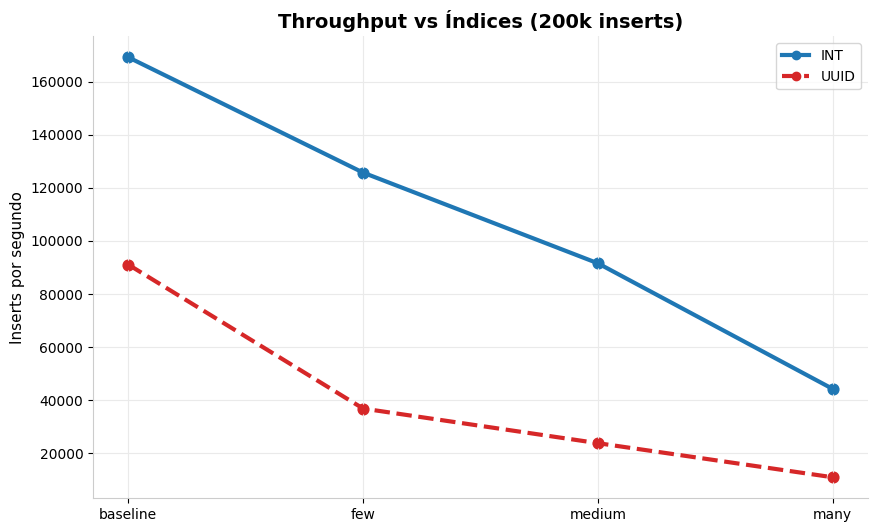

In [5]:
df_200k = df[df["rows"] == 200000]
pivot = df_200k.pivot(index="scenario", columns="type", values="throughput")
pivot = pivot.loc[order]

fig, ax = plt.subplots()

# linhas
ax.plot(
    pivot.index,
    pivot["INT"],
    marker='o',
    linewidth=3,
    label="INT",
    color=INT_COLOR
)

ax.plot(
    pivot.index,
    pivot["UUID"],
    marker='o',
    linewidth=3,
    linestyle="--",
    label="UUID",
    color=UUID_COLOR
)

# pontos
ax.scatter(pivot.index, pivot["INT"], s=60, color=INT_COLOR)
ax.scatter(pivot.index, pivot["UUID"], s=60, color=UUID_COLOR)

ax.set_title("Throughput vs Índices (200k inserts)")
ax.set_ylabel("Inserts por segundo")
ax.set_xlabel("")

ax.legend()

# remove bordas feias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ===== 💣 ANOTAÇÃO LIMPA =====
baseline = pivot.loc["baseline", "INT"]
worst = pivot.loc["many", "UUID"]

drop = 100 * (1 - worst / baseline)

plt.show()

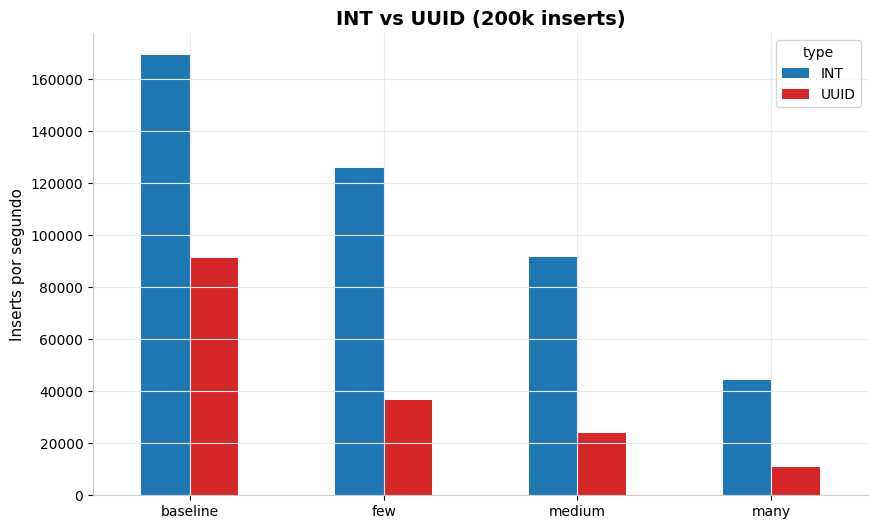

In [6]:
compare = df[df["rows"] == 200000].pivot(index="scenario", columns="type", values="throughput")
compare = compare.loc[order]

fig, ax = plt.subplots()

compare.plot(
    kind="bar",
    ax=ax,
    color=[INT_COLOR, UUID_COLOR]
)

ax.set_title("INT vs UUID (200k inserts)")
ax.set_ylabel("Inserts por segundo")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)

plt.show()

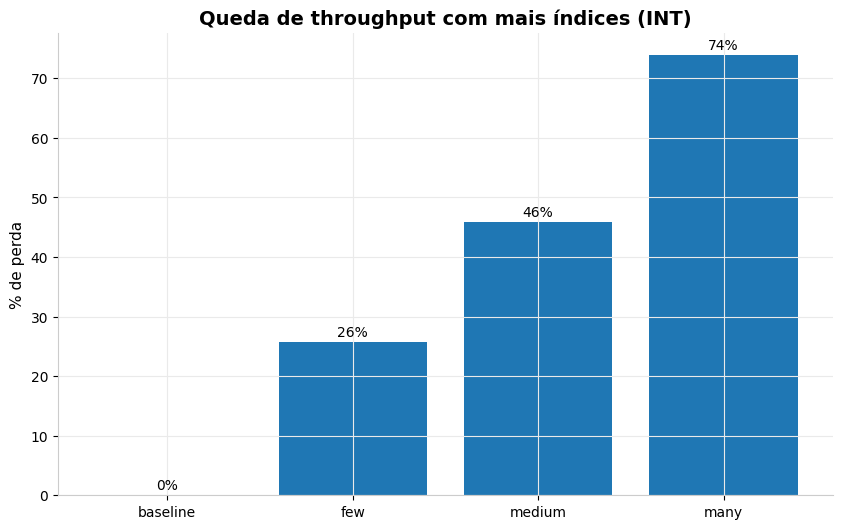

In [7]:
df_int_200k = df[(df.type=="INT") & (df.rows==200000)].copy()
df_int_200k = df_int_200k.set_index("scenario").loc[order]

baseline_int = df_int_200k.loc["baseline", "throughput"]
df_int_200k["drop_pct"] = 100 * (1 - df_int_200k["throughput"] / baseline_int)

fig, ax = plt.subplots()

bars = ax.bar(df_int_200k.index, df_int_200k["drop_pct"], color=INT_COLOR)

ax.set_title("Queda de throughput com mais índices (INT)")
ax.set_ylabel("% de perda")
ax.set_xlabel("")

# labels nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.0f}%",
        ha='center',
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)

plt.show()

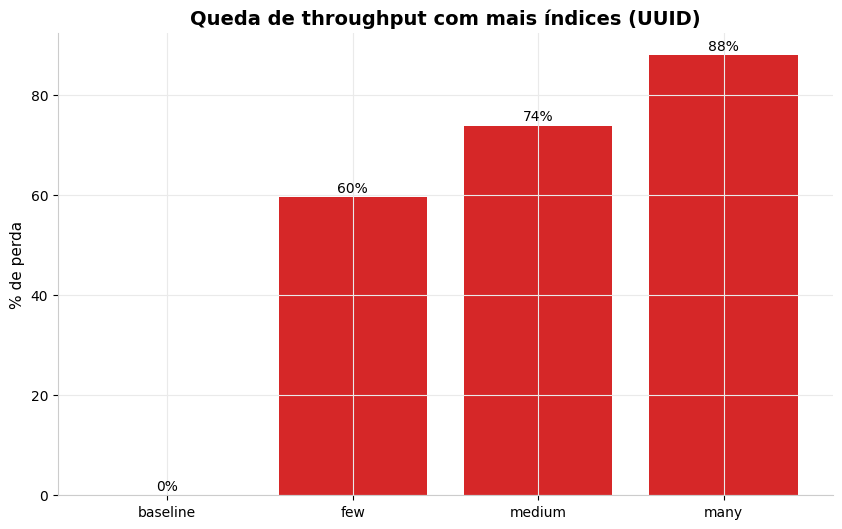

In [8]:
df_uuid_200k = df[(df.type=="UUID") & (df.rows==200000)].copy()
df_uuid_200k = df_uuid_200k.set_index("scenario").loc[order]

baseline_uuid = df_uuid_200k.loc["baseline", "throughput"]
df_uuid_200k["drop_pct"] = 100 * (1 - df_uuid_200k["throughput"] / baseline_uuid)

fig, ax = plt.subplots()

bars = ax.bar(df_uuid_200k.index, df_uuid_200k["drop_pct"], color=UUID_COLOR)

ax.set_title("Queda de throughput com mais índices (UUID)")
ax.set_ylabel("% de perda")
ax.set_xlabel("")

# labels nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.0f}%",
        ha='center',
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)

plt.show()

In [9]:
baseline_int = df[(df.type=="INT") & (df.rows==200000) & (df.scenario=="baseline")]["throughput"].values[0]
worst_uuid = df[(df.type=="UUID") & (df.rows==200000) & (df.scenario=="many")]["throughput"].values[0]

drop = 100 * (1 - worst_uuid / baseline_int)

print(f"Queda total: {drop:.1f}%")
print(f"De {baseline_int:.0f} → {worst_uuid:.0f} inserts/s")

Queda total: 93.5%
De 169207 → 10927 inserts/s
